# Evaluación del modelo — Análisis en profundidad

En este notebook se realiza el análisis completo del mejor modelo seleccionado en `03_models.ipynb` (LightGBM optimizado). El objetivo es evaluar su comportamiento desde distintos ángulos relevantes para la aplicación clínica:

- **Curvas ROC y Precision-Recall** — capacidad discriminativa
- **Importancia de variables** — qué factores contribuyen más a la predicción
- **Análisis de umbral** — cómo afecta el umbral al trade-off precision/recall
- **Calibración y Brier Score** — fiabilidad de las probabilidades predichas
- **Decision Curve Analysis (DCA)** — utilidad clínica neta del modelo
- **Interpretabilidad SHAP** — explicación global e individual de las predicciones

## 1. Imports y carga del modelo

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.evaluation.evaluate import (
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_calibration_curve,
    brier_score,
    plot_dca,
    plot_shap_summary,
    get_classification_report,
    threshold_analysis
)

In [ ]:
# Cargamos el mejor modelo guardado por el notebook 03
model_files = glob.glob("../models/*.pkl")
if not model_files:
    raise FileNotFoundError("No se encontró ningún modelo en models/. Ejecuta primero 03_models.ipynb")

model_path = model_files[0]
best_model = joblib.load(model_path)

# Nombre legible para títulos y gráficos
_raw_name = os.path.basename(model_path).replace(".pkl", "")
_name_map = {
    "lightgbm_optimizado": "LightGBM Optimizado",
    "xgboost_optimizado":  "XGBoost Optimizado",
}
best_model_name = _name_map.get(_raw_name, _raw_name.replace("_", " ").title())

print(f"Modelo cargado: {best_model_name}")
print(f"Ruta: {model_path}")

In [3]:
X, y, groups = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train:      {X_train.shape[0]:,} registros")
print(f"Validación: {X_val.shape[0]:,} registros")
print(f"Test:       {X_test.shape[0]:,} registros  ← conjunto de evaluación final")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Train:      189,245 registros
Validación: 62,611 registros
Test:       64,126 registros  ← conjunto de evaluación final


## 2. Curva ROC

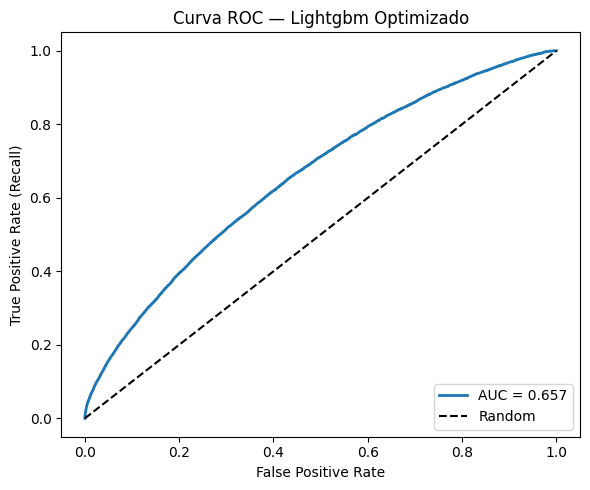

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_roc_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/roc_best_model.png"
)
plt.tight_layout()
plt.show()

## 3. Curva Precision-Recall

La curva Precision-Recall complementa la ROC en escenarios con clases desbalanceadas. Muestra el trade-off entre detectar pacientes en riesgo (recall) y la fiabilidad de esas alertas (precision).

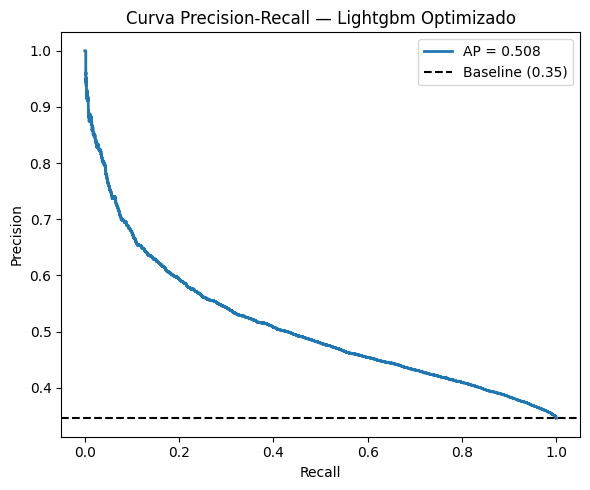

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_precision_recall_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/pr_curve_best_model.png"
)
plt.tight_layout()
plt.show()

## 4. Matriz de confusión y reporte de clasificación

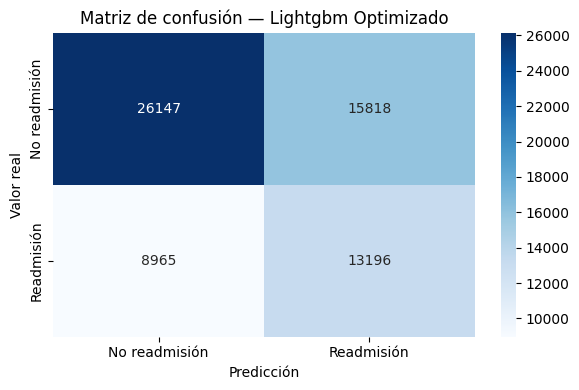

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion_matrix(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/confusion_matrix_best_model.png"
)
plt.tight_layout()
plt.show()

In [7]:
get_classification_report(best_model, X_test, y_test)

,precision,recall,f1-score,support
No readmisión,0.745,0.623,0.678,41965.000
Readmisión,0.455,0.595,0.516,22161.000
accuracy,0.614,0.614,0.614,0.614
macro avg,0.600,0.609,0.597,64126.000
weighted avg,0.645,0.614,0.622,64126.000


## 5. Importancia de variables

El análisis de importancia de variables permite identificar qué factores clínicos y demográficos contribuyen más a la predicción de readmisión, aportando interpretabilidad al modelo.

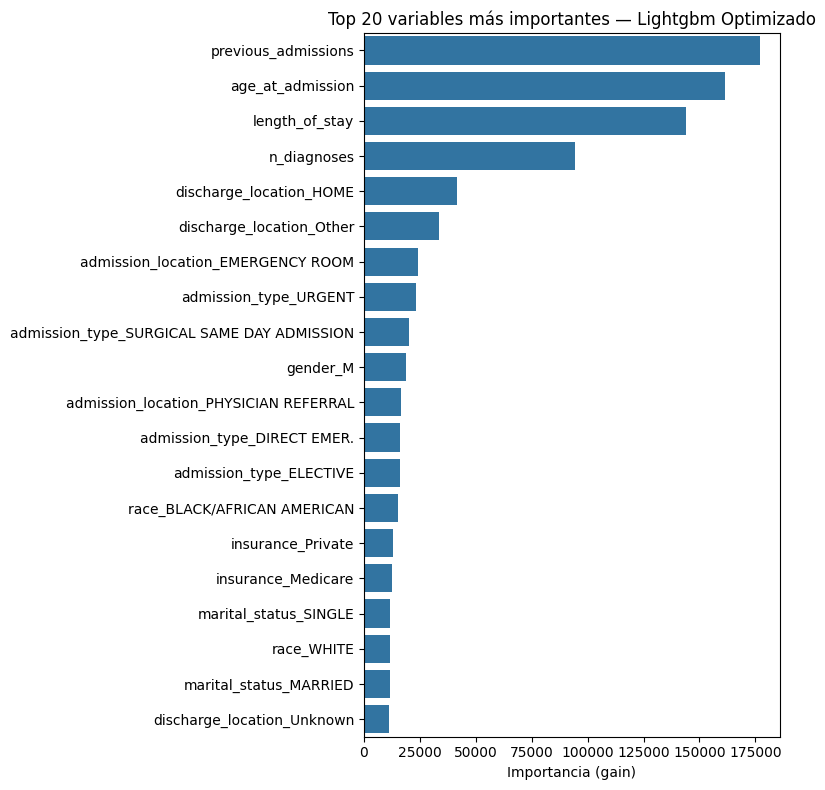

,feature,importance
2,previous_admissions,177146.596448
3,age_at_admission,161495.803133
0,length_of_stay,143753.698553
1,n_diagnoses,94478.837742
48,discharge_location_HOME,41413.855104
50,discharge_location_Other,33579.713314
39,admission_location_EMERGENCY ROOM,23994.674311
37,admission_type_URGENT,23243.073330
36,admission_type_SURGICAL SAME DAY ADMISSION,20286.089044
4,gender_M,19007.608747


In [8]:
importance_df = plot_feature_importance(
    best_model,
    feature_names=X.columns.tolist(),
    model_name=best_model_name,
    top_n=20,
    save_path="../results/feature_importance_best_model.png"
)
importance_df

## 6. Análisis de umbral de decisión

El umbral por defecto (0.5) no es siempre el óptimo en contexto clínico. Si el objetivo es detectar el máximo número de pacientes en riesgo (maximizar recall), puede ser preferible bajar el umbral, asumiendo más falsos positivos.

**Metodología:** el umbral óptimo se selecciona sobre el conjunto de **validación** (nunca sobre test) y se valida su rendimiento sobre el **test set** para obtener métricas finales sin sesgo de selección.

=== Selección de umbral (conjunto de validación) ===


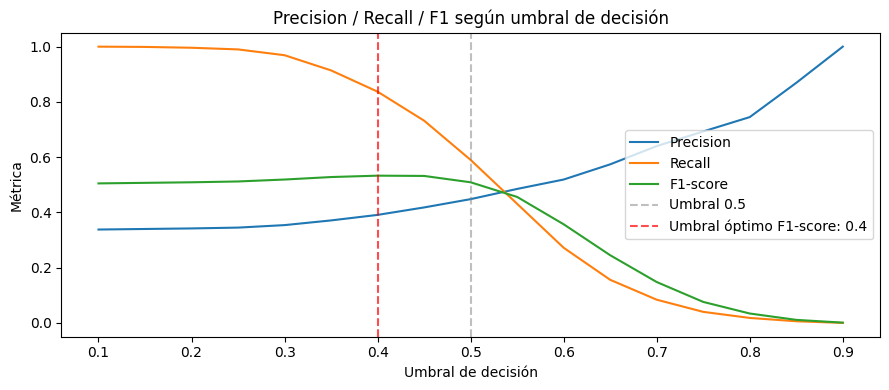


Umbral óptimo (F1-score): 0.4
Precision    0.391
Recall       0.837
F1-score     0.533

=== Evaluación del umbral óptimo (0.4) sobre test set ===

Comparación umbral 0.5 vs umbral óptimo (test set):
        Precision  Recall  F1-score
Umbral                             
0.5        0.4548  0.5955    0.5157
0.4        0.3993  0.8406    0.5414


,Precision,Recall,F1-score
Umbral,,,
0.5,0.4548,0.5955,0.5157
0.4,0.3993,0.8406,0.5414


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Paso 1 — Selección del umbral óptimo sobre VALIDACIÓN
print("=== Selección de umbral (conjunto de validación) ===")
threshold_df_val = threshold_analysis(best_model, X_val, y_val)
optimal_threshold = threshold_df_val["F1-score"].idxmax()

# Paso 2 — Validación del umbral seleccionado sobre TEST (evaluación final)
print(f"\n=== Evaluación del umbral óptimo ({optimal_threshold}) sobre test set ===")
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_optimal = (y_prob_test >= optimal_threshold).astype(int)

results_threshold = {
    "Umbral":     optimal_threshold,
    "Precision":  round(precision_score(y_test, y_pred_optimal, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_optimal, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_optimal, zero_division=0), 4),
}

# Comparación con umbral 0.5 sobre test
y_pred_05 = (y_prob_test >= 0.5).astype(int)
results_default = {
    "Umbral":     0.5,
    "Precision":  round(precision_score(y_test, y_pred_05, zero_division=0), 4),
    "Recall":     round(recall_score(y_test, y_pred_05, zero_division=0), 4),
    "F1-score":   round(f1_score(y_test, y_pred_05, zero_division=0), 4),
}

comparison = pd.DataFrame([results_default, results_threshold]).set_index("Umbral")
print("\nComparación umbral 0.5 vs umbral óptimo (test set):")
print(comparison.to_string())
comparison

## 7. Calibración y Brier Score

Un modelo bien calibrado es fundamental en contexto clínico: si predice un 70% de probabilidad de reingreso, eso debería corresponder aproximadamente a una tasa real del 70%. La curva de calibración (reliability diagram) muestra visualmente esta correspondencia. El Brier Score complementa la curva con un valor numérico del error cuadrático medio entre probabilidades predichas y etiquetas reales.

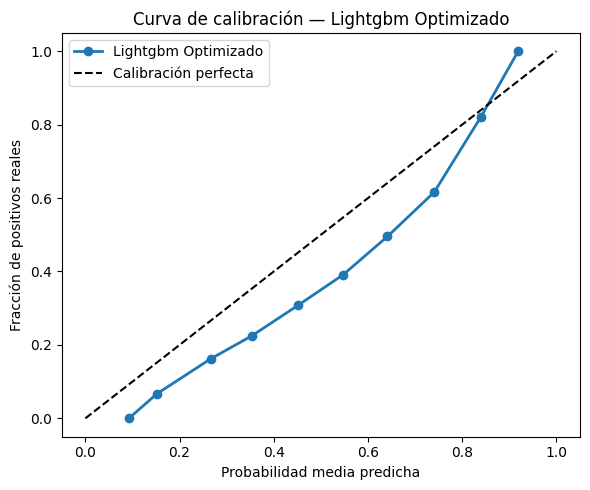


Brier Score:  0.2290
Baseline:     0.2262  (prediciendo siempre la prevalencia)
Mejora:       -0.0028


0.22899374987154333

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/calibration_best_model.png"
)
plt.tight_layout()
plt.show()

print()
brier_score(best_model, X_test, y_test)

## 8. Decision Curve Analysis (DCA)

La DCA evalúa la utilidad clínica neta del modelo comparándolo con las dos estrategias extremas: tratar a todos los pacientes (ignorar el modelo) o no tratar a ninguno. Si la curva del modelo queda por encima de ambas alternativas en un rango de umbrales, el modelo aporta valor real en ese rango de decisión clínica.

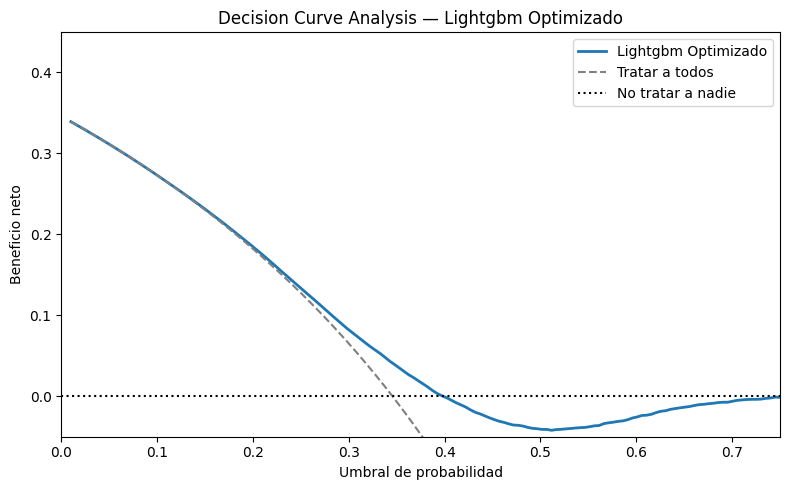

,threshold,net_benefit_model,net_benefit_all
0,0.010000,0.338975,0.338975
1,0.014966,0.335642,0.335642
2,0.019933,0.332276,0.332276
3,0.024899,0.328875,0.328875
4,0.029866,0.325439,0.325439
5,0.034832,0.321968,0.321968
6,0.039799,0.318461,0.318461
7,0.044765,0.314917,0.314917
8,0.049732,0.311337,0.311337
9,0.054698,0.307719,0.307719


In [11]:
dca_df = plot_dca(
    best_model, X_test, y_test,
    model_name=best_model_name,
    save_path="../results/dca_best_model.png"
)
dca_df.head(10)

## 9. Interpretabilidad SHAP

SHAP explica cuánto contribuye cada variable a cada predicción concreta. 
A diferencia de la importancia por ganancia (sección 5), tiene en cuenta cómo interactúan las variables entre sí. 
Los valores tienen signo: positivo empuja hacia predecir reingreso, negativo hacia no reingreso.

Se utiliza una muestra de 2.000 registros del test set para reducir el tiempo de cómputo sin perder representatividad.

c:\Users\skipe\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


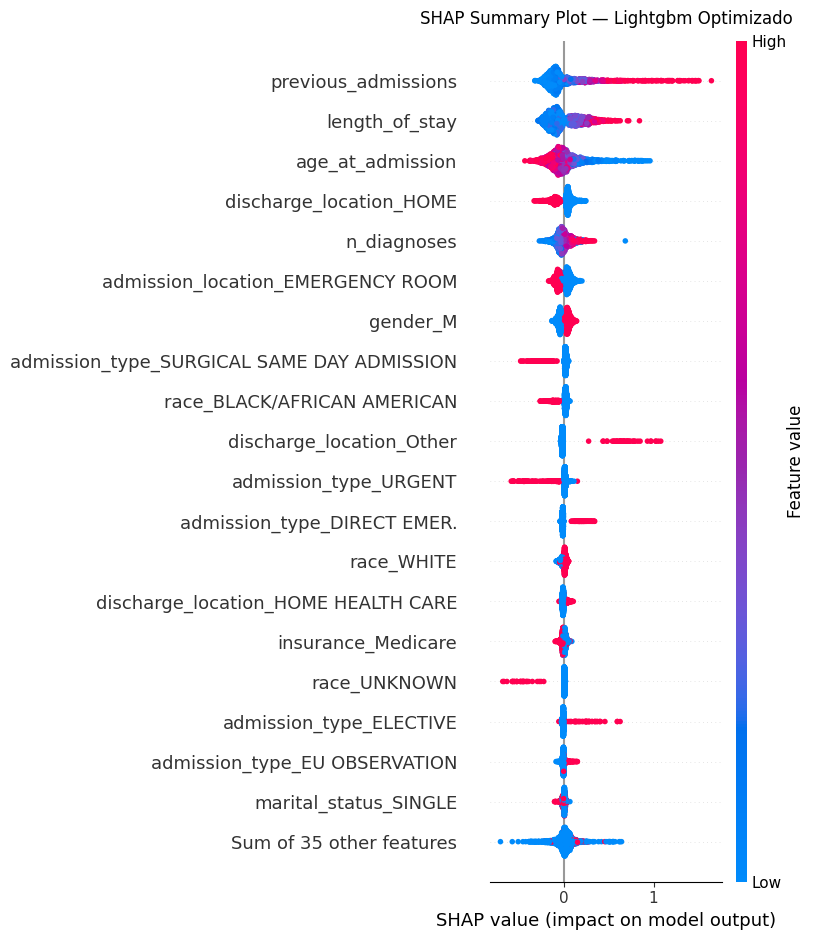

,feature,mean_abs_shap
0,previous_admissions,0.170462
1,length_of_stay,0.147498
2,age_at_admission,0.124533
3,discharge_location_HOME,0.075954
4,n_diagnoses,0.063338
5,admission_location_EMERGENCY ROOM,0.056908
6,gender_M,0.048645
7,admission_type_SURGICAL SAME DAY ADMISSION,0.041219
8,race_BLACK/AFRICAN AMERICAN,0.036461
9,discharge_location_Other,0.033146


In [12]:
X_sample = X_test.sample(n=2000, random_state=42)

shap_df = plot_shap_summary(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=20,
    save_path="../results/shap_summary_best_model.png"
)
shap_df

## 10. Conclusiones

Este análisis evalúa el modelo LightGBM optimizado desde los ángulos más relevantes para su posible uso clínico:

- La **curva ROC** y la **curva Precision-Recall** confirman la capacidad discriminativa del modelo (AUC ~0.66), coherente con la literatura de reingreso a 30 días con datos administrativos.
- La **importancia de variables** y los **valores SHAP** identifican los factores clínicos con mayor peso en la predicción, aportando interpretabilidad al modelo más allá de las métricas agregadas.
- El **análisis de umbral** permite ajustar el punto de corte según la tolerancia clínica al riesgo — bajando el umbral se detectan más reingresos a costa de más falsos positivos.
- La **calibración** y el **Brier Score** (0.229 vs baseline 0.226) indican una calibración ligeramente peor que predecir siempre la prevalencia, lo que sugiere que las probabilidades predichas deben interpretarse con cautela como estimaciones de riesgo individual.
- La **DCA** muestra en qué rango de umbrales el modelo ofrece beneficio neto real frente a tratar a todos o no tratar a nadie.

**Nota metodológica — división por paciente:** los datos se dividen usando `GroupShuffleSplit` por `subject_id`, evitando que el mismo paciente aparezca en más de un conjunto. Al comparar con la división aleatoria por admisión (versión anterior del proyecto), las métricas varían menos de 0.002 AUC. Esto confirma que el modelo no dependía de leakage entre admisiones del mismo paciente para obtener su rendimiento, y que la capacidad discriminativa observada es real.